In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


INSPECTING DATA



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum() #column wise
df.isnull().sum().sum() #overall null

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum() #overall
df["customerID"].duplicated().sum() #based on customer id

np.int64(0)

convert 0 and 1 val of senior citizen to yes or no

In [9]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


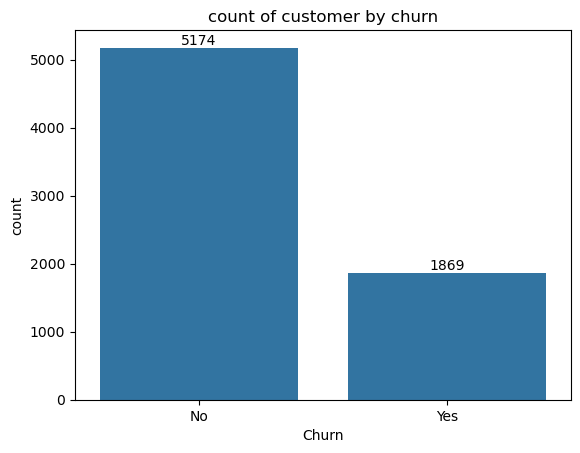

In [10]:
ax = sns.countplot(x = 'Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title("count of customer by churn")
plt.show()

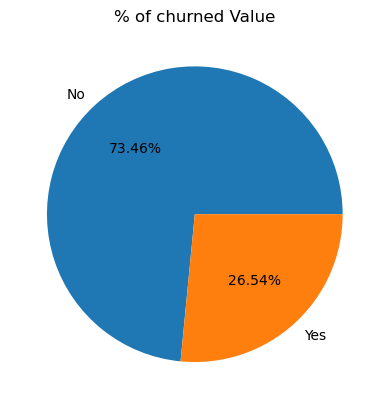

In [11]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%4.2f%%") 
plt.title("% of churned Value")
plt.show()

lets explore the reason behind Churning

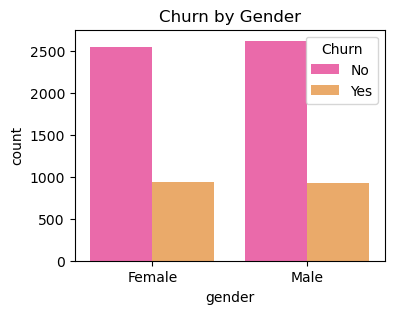

In [12]:
plt.figure(figsize = (4,3))
sns.countplot(x = "gender", data = df, hue = "Churn",palette = "spring")
plt.title("Churn by Gender")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_24652\648607159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = "SeniorCitizen", data = df,palette = "spring")


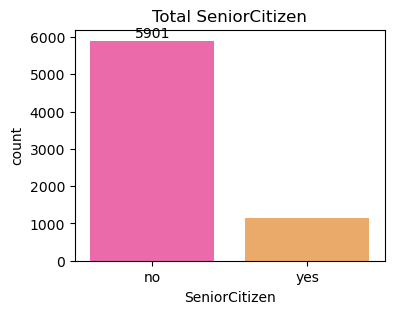

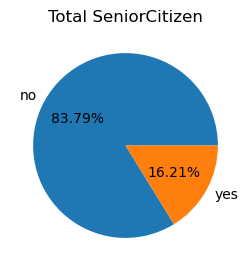

In [13]:
plt.figure(figsize = (4,3))
ax = sns.countplot(x = "SeniorCitizen", data = df,palette = "spring")
ax.bar_label(ax.containers[0])
plt.title("Total SeniorCitizen")
plt.show()

import matplotlib.pyplot as plt

# Step 1: Count values of SeniorCitizen
counts = df["SeniorCitizen"].value_counts()  # returns a Series

# Step 2: Plot pie chart
plt.figure(figsize=(4,3))
plt.pie(
    counts,                              # sizes of slices
    labels=counts.index,                 # category labels (0, 1)
    autopct="%1.2f%%",                    # display percentages
)

# Step 3: Title and show
plt.title("Total SeniorCitizen")
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_24652\845441916.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(idx, bottom_vals[idx] + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=8)


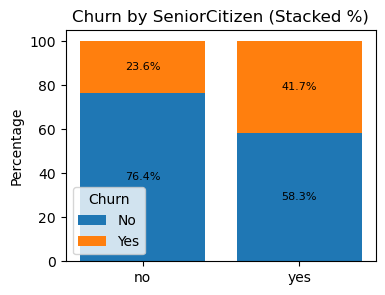

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Prepare the percentage data
counts = df.groupby(["SeniorCitizen", "Churn"]).size().reset_index(name="count")

# Pivot so 'Churn' categories become columns
pivot_df = counts.pivot(index="SeniorCitizen", columns="Churn", values="count").fillna(0)

# Calculate percentages
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Step 2: Plot stacked bar
fig, ax = plt.subplots(figsize=(4, 3))

bottom_vals = None
for churn_value in percent_df.columns:
    ax.bar(
        percent_df.index, 
        percent_df[churn_value], 
        label=churn_value, 
        bottom=bottom_vals
    )
    bottom_vals = percent_df[churn_value] if bottom_vals is None else bottom_vals + percent_df[churn_value]

# Step 3: Add percentage labels
bottom_vals = [0] * len(percent_df)
for churn_value in percent_df.columns:
    for idx, val in enumerate(percent_df[churn_value]):
        ax.text(idx, bottom_vals[idx] + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=8)
    bottom_vals = bottom_vals + percent_df[churn_value]

# Step 4: Formatting
ax.set_title("Churn by SeniorCitizen (Stacked %)")
ax.set_ylabel("Percentage")
ax.legend(title="Churn")

plt.show()


comparatively a greater percentage of people in senior citizen category have churned

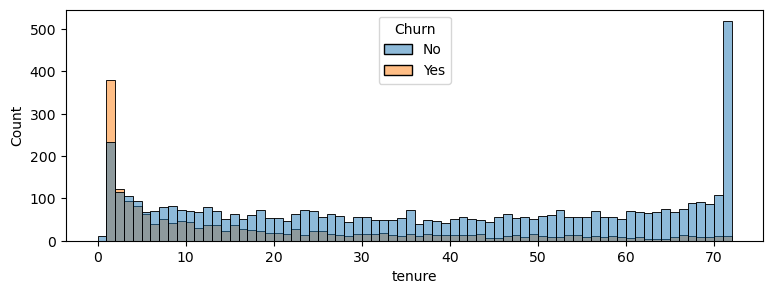

In [15]:
plt.figure(figsize = (9,3))
sns.histplot(x = "tenure", data = df,bins = 72, hue = "Churn")
plt.show()

people who have used our service for long time have stayed and people
who have used our services for 1 or 2 months have churned

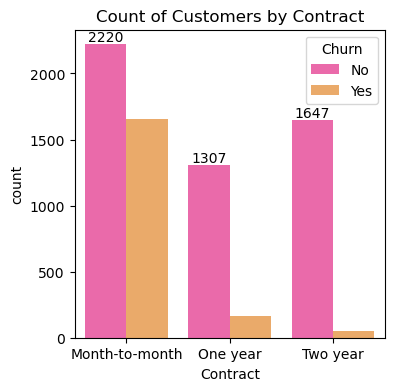

In [16]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df,palette = "spring",hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()


people with month to month contract are likely to churn
than from those who have 1 to 2 years of Contracts

In [17]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

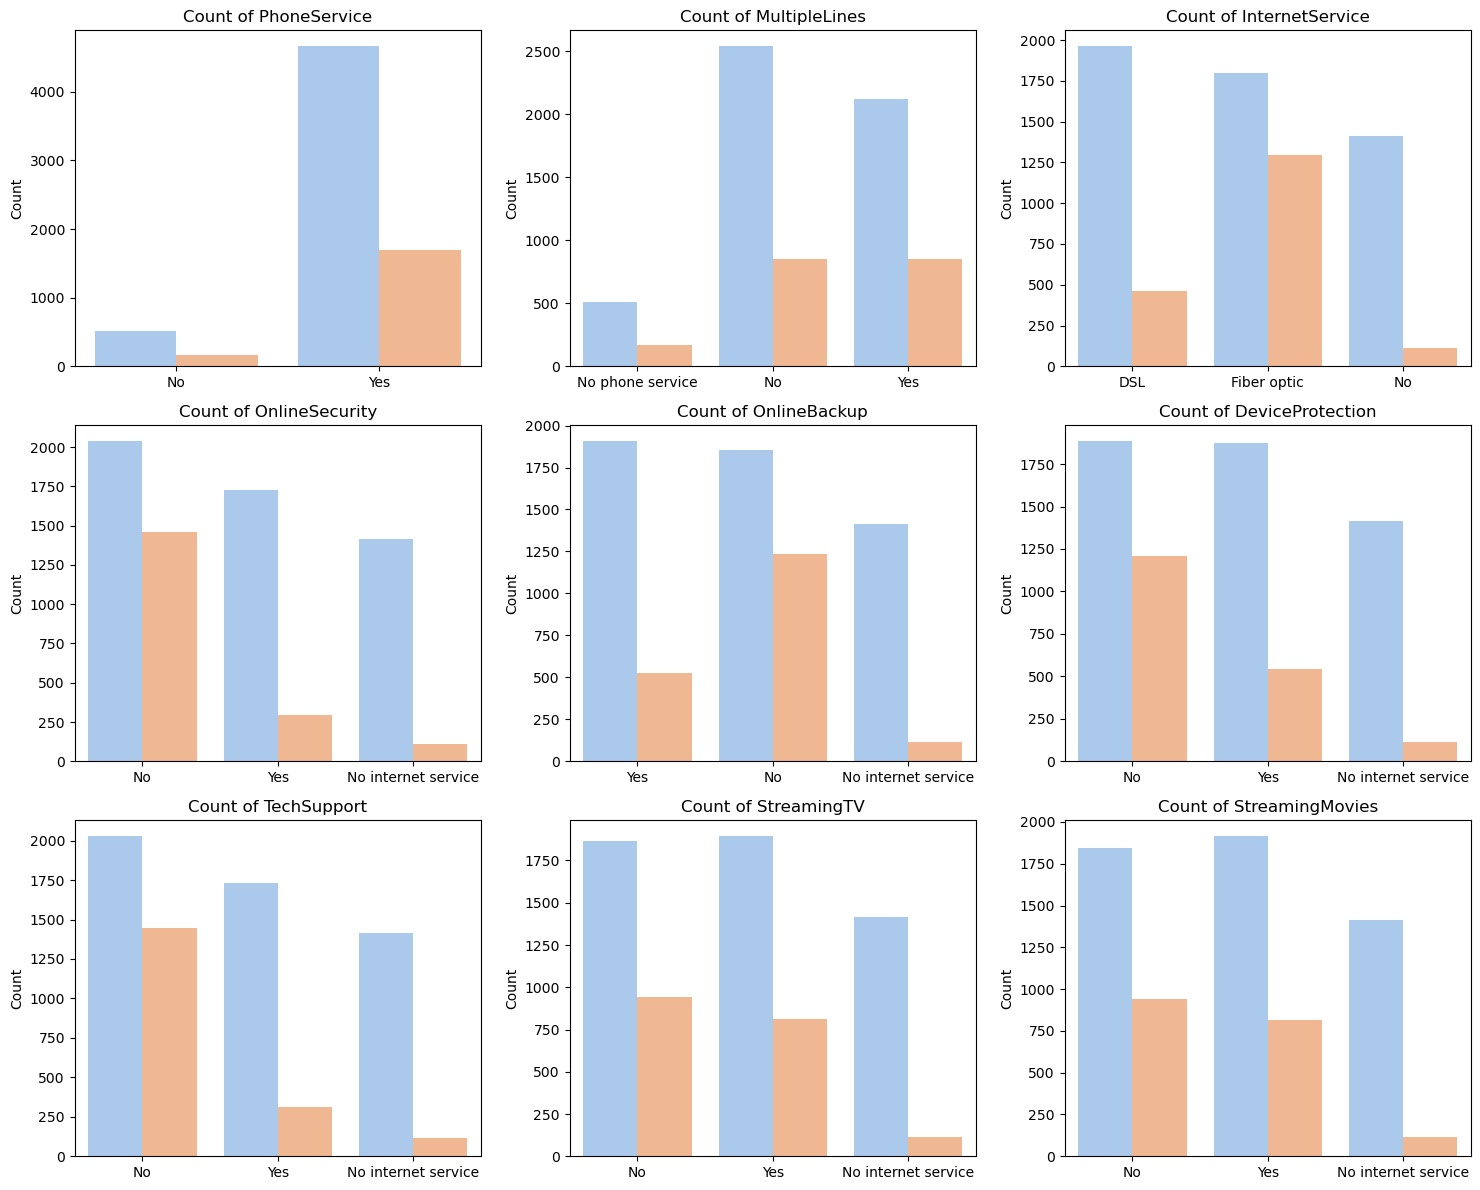

In [18]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue=df["Churn"], palette="pastel", legend=False, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# remove empty subplot(s) if any
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Most customers have PhoneService, but a significant portion with it still churn.
Services like OnlineSecurity, TechSupport, and DeviceProtection show that churn is higher among customers who opted for "No".
Customers with Fiber optic Internet tend to churn more compared to DSL users.
Streaming services (TV/Movies) don’t strongly prevent churn; both "Yes" and "No" categories show notable churn counts.
    
=> Overall, lack of security/tech-support services and Fiber optic plans appear linked to higher churn.

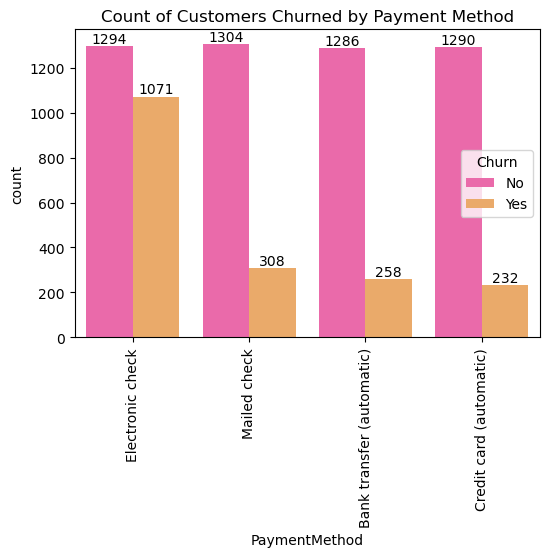

In [19]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df,palette = "spring",hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation = 90)
plt.title("Count of Customers Churned by Payment Method")
plt.show()


Customers paying through Electronic Checks show the highest churn, highlighting the risk with flexible payment methods.
Mailed Checks have moderate churn, while automatic payments (Credit Card/Bank Transfer) show the lowest churn.
This indicates that encouraging customers to shift towards auto-pay options could help reduce churn significantly.

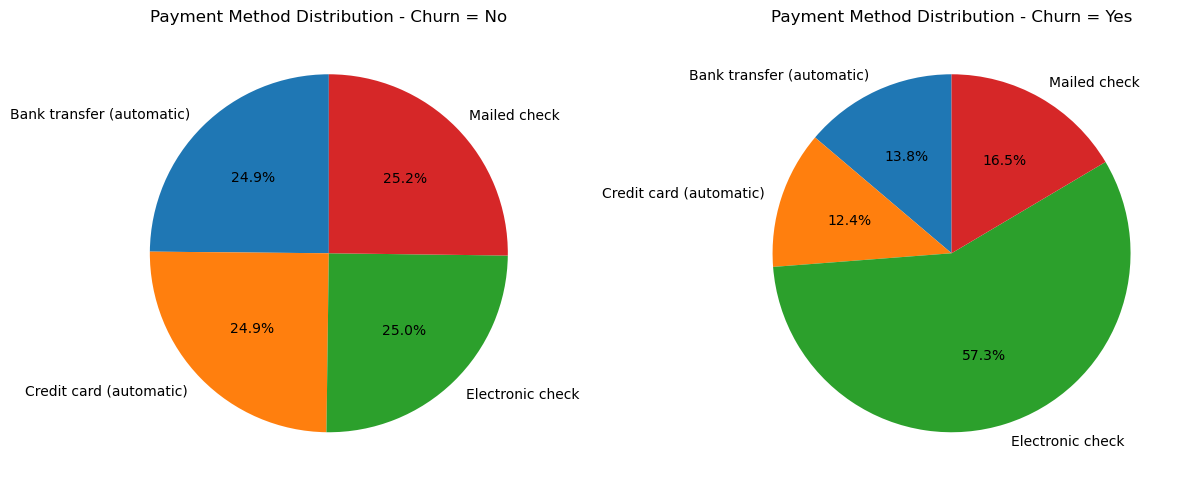

In [20]:
import matplotlib.pyplot as plt

# Group by PaymentMethod and Churn
payment_churn = df.groupby(["PaymentMethod", "Churn"]).size().reset_index(name="Count")

# Plot pie chart for each churn status
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, status in enumerate(payment_churn["Churn"].unique()):
    data = payment_churn[payment_churn["Churn"] == status]
    axes[i].pie(
        data["Count"], 
        labels=data["PaymentMethod"], 
        autopct="%1.1f%%", 
        startangle=90
       
    )
    axes[i].set_title(f"Payment Method Distribution - Churn = {status}")

plt.tight_layout()
plt.show()


Payment method vs Contract: is the e-check effect real?

Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)           0.381     0.253     0.365
Credit card (automatic)             0.357     0.261     0.382
Electronic check                    0.782     0.147     0.071
Mailed check                        0.554     0.209     0.237
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Contract                                                             
Month-to-month                       34.1                     32.8   
One year                              9.7                     10.3   
Two year                              3.4                      2.2   

PaymentMethod   Electronic check  Mailed check  
Contract                                        
Month-to-month              53.7          31.6  
One year                    18.4           6.8  
Two year                     7.7           0.8  


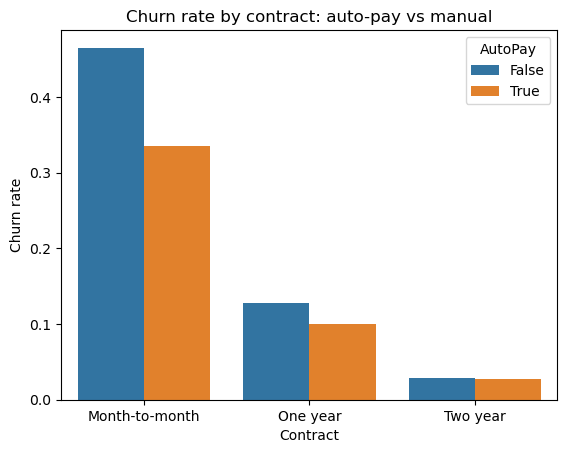

In [21]:
df["Churn_flag"] = (df["Churn"] == "Yes").astype(int)
df["AutoPay"] = df["PaymentMethod"].str.contains("automatic")

# Contract mix by payment method
print(pd.crosstab(df["PaymentMethod"], df["Contract"], normalize="index").round(3))

# Churn rate by payment method within each contract
rate = (df.groupby(["Contract", "PaymentMethod"])["Churn_flag"].mean() * 100).round(1)
print(rate.unstack())

# Plot
sns.barplot(data=df, x="Contract", y="Churn_flag", hue="AutoPay", errorbar=None)
plt.title("Churn rate by contract: auto-pay vs manual")
plt.ylabel("Churn rate")
plt.show()

Electronic check users are 78% month-to-month, so part of their higher churn comes from contract type. Within month-to-month contracts, e-check still churns at 53.7% vs ~33% for auto-pay.

Churn rates by feature (rates, not just counts)
Counts are misleading when groups differ in size, so the charts below show the churn rate within each group. The dashed line is the overall churn rate (26.5%).

In [23]:
overall = df["Churn_flag"].mean() * 100

def rate_plot(col, ax, order=None, title=None):
    rate = df.groupby(col, observed=True)["Churn_flag"].mean().mul(100)
    if order is not None:
        rate = rate.reindex(order)
    sns.barplot(x=rate.index.astype(str), y=rate.values, color="#4C78A8", ax=ax)
    ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=8)
    ax.axhline(overall, ls="--", color="grey", lw=1)
    ax.set_title(title or f"Churn rate by {col}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate (%)")
    ax.set_ylim(0, rate.max() * 1.2)
    return rate

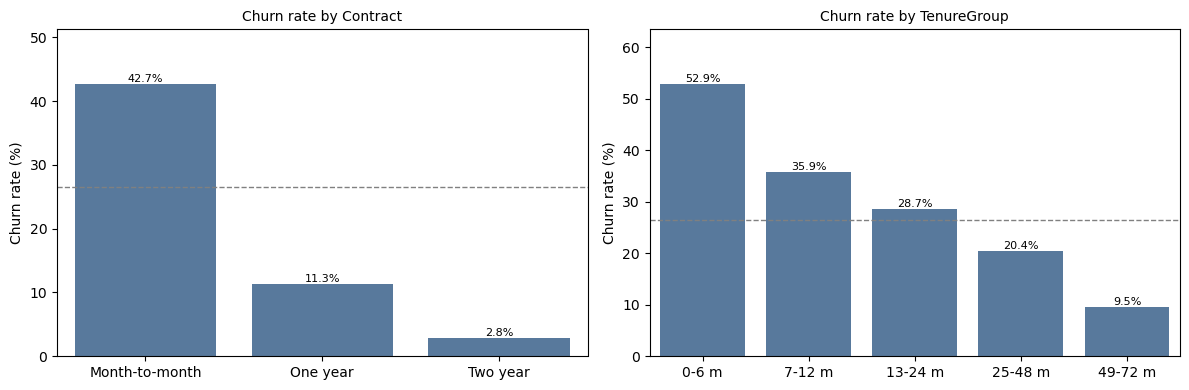

In [24]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                           labels=["0-6 m", "7-12 m", "13-24 m", "25-48 m", "49-72 m"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rate_plot("Contract", axes[0], ["Month-to-month", "One year", "Two year"])
rate_plot("TenureGroup", axes[1])
plt.tight_layout()
plt.show()

Churn falls steadily with tenure (52.9% in the first 6 months vs 9.5% after 4 years) and is far higher on month-to-month contracts (42.7%) than on two-year contracts (2.8%). The first six months are the highest-risk window.

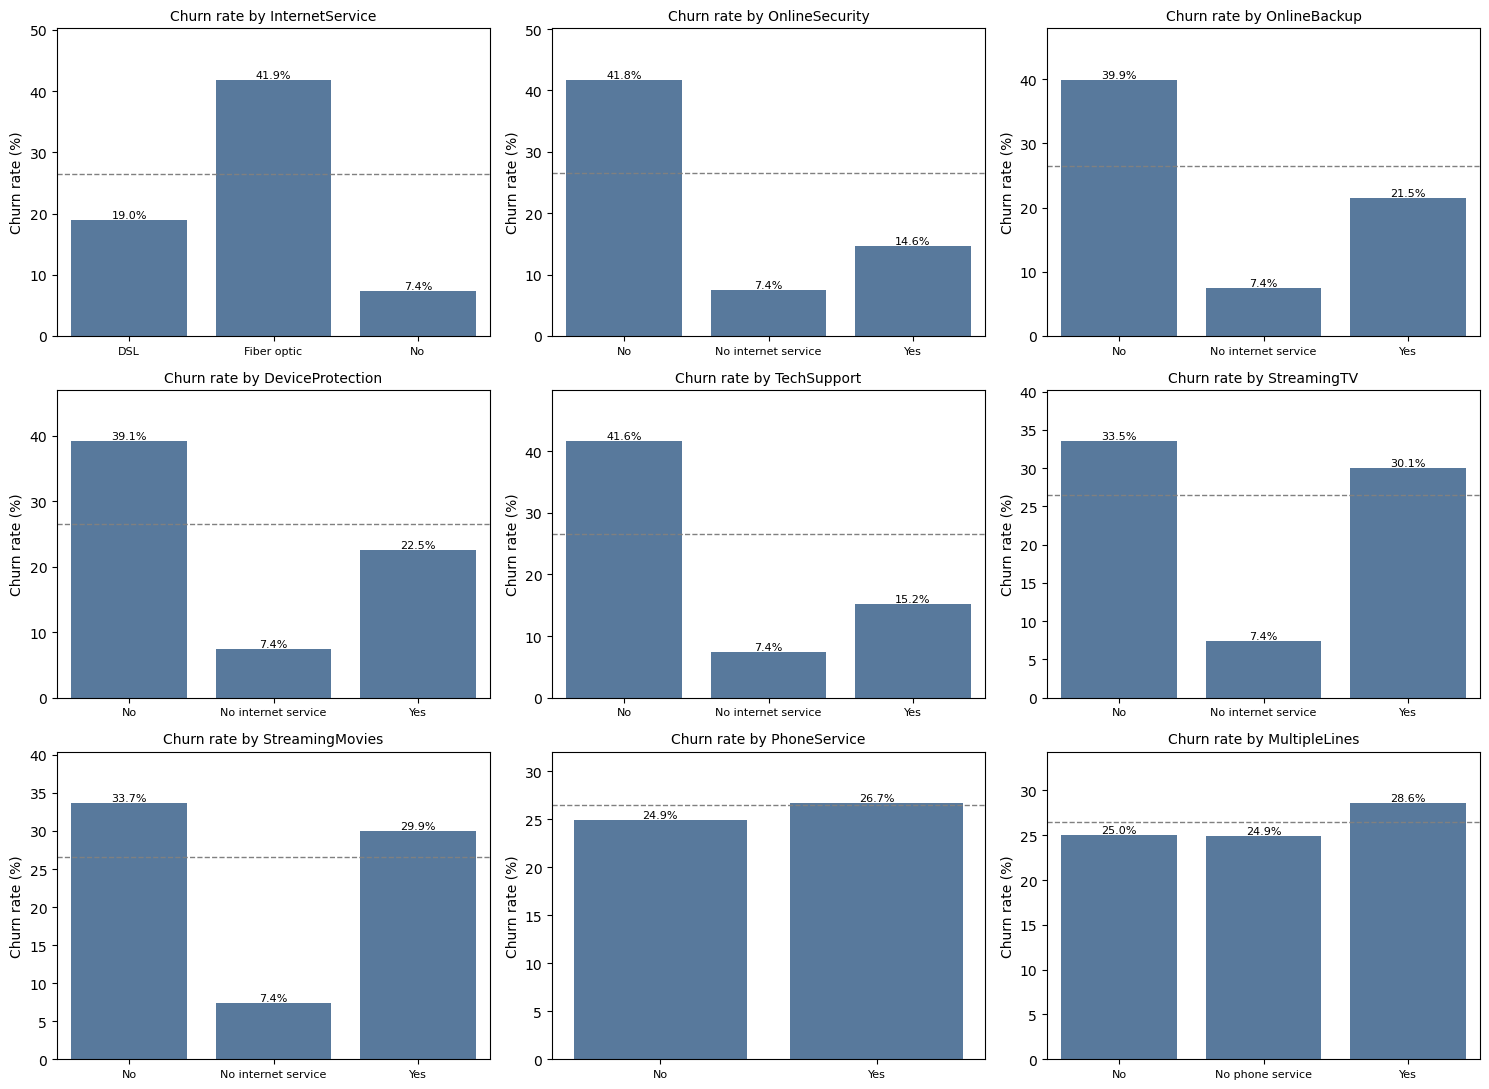

In [25]:
services = ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "PhoneService", "MultipleLines"]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), services):
    rate_plot(col, ax)
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

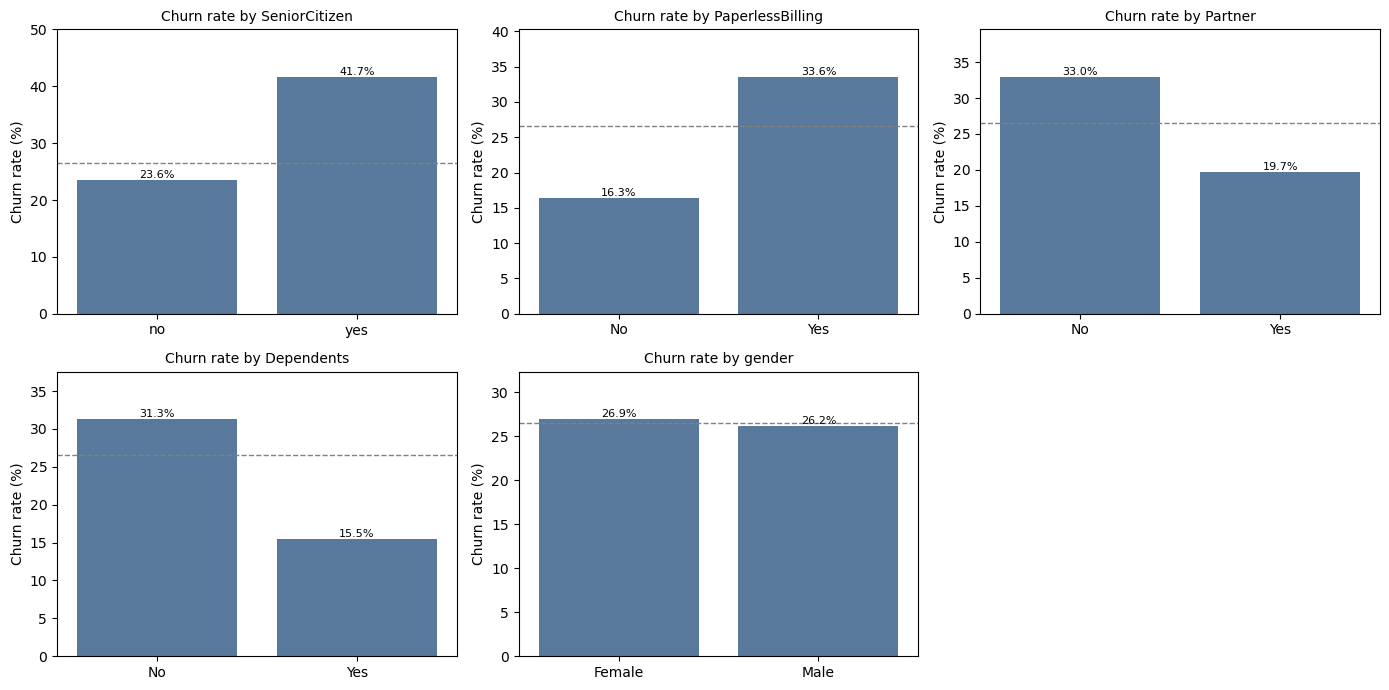

In [26]:
profile = ["SeniorCitizen", "PaperlessBilling", "Partner", "Dependents", "gender"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), profile):
    rate_plot(col, ax)
axes.flatten()[5].axis("off")
plt.tight_layout()
plt.show()

In [27]:
net = df[df["InternetService"] != "No"].copy()
net["Protection"] = np.where((net["OnlineSecurity"] == "Yes") & (net["TechSupport"] == "Yes"), "Both",
                     np.where((net["OnlineSecurity"] == "No") & (net["TechSupport"] == "No"), "Neither", "One only"))

summary = net.groupby("Protection")["Churn_flag"].agg(["count", "mean"])
summary["mean"] = (summary["mean"] * 100).round(1)
summary.columns = ["customers", "churn_rate_%"]
summary

,customers,churn_rate_%
Protection,,
Both,1099,9.0
Neither,2553,49.0
One only,1865,21.8


In [28]:
rows = []
for col in ["TenureGroup", "Contract", "InternetService", "PaymentMethod",
            "SeniorCitizen", "PaperlessBilling", "Dependents", "Partner", "gender"]:
    r = df.groupby(col, observed=True)["Churn_flag"].mean() * 100
    rows.append((col, r.idxmax(), round(r.max(), 1), r.idxmin(), round(r.min(), 1), round(r.max() - r.min(), 1)))

pd.DataFrame(rows, columns=["feature", "highest", "highest_%", "lowest", "lowest_%", "spread_pts"]) \
  .sort_values("spread_pts", ascending=False).reset_index(drop=True)

,feature,highest,highest_%,lowest,lowest_%,spread_pts
0,TenureGroup,0-6 m,52.9,49-72 m,9.5,43.4
1,Contract,Month-to-month,42.7,Two year,2.8,39.9
2,InternetService,Fiber optic,41.9,No,7.4,34.5
3,PaymentMethod,Electronic check,45.3,Credit card (automatic),15.2,30.0
4,SeniorCitizen,yes,41.7,no,23.6,18.1
5,PaperlessBilling,Yes,33.6,No,16.3,17.2
6,Dependents,No,31.3,Yes,15.5,15.8
7,Partner,No,33.0,Yes,19.7,13.3
8,gender,Female,26.9,Male,26.2,0.8


Note: these are associations, not causes. Tenure, contract type, internet service and payment method overlap heavily (for example, 78% of e-check users are month-to-month), so the ranking above shows where churn concentrates, not what causes it. Gender has no meaningful effect.